In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
sns.set_theme(style='whitegrid')

In [66]:
#1
elya=pd.read_csv('catalog.csv')
print('--'*30)
display(elya.head())
print('--'*30)
print('Cound:',{elya.shape})
print('--'*30)
print(elya.dtypes)


------------------------------------------------------------


,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50
0,Home,762,303,Electronics,49,348,Clothing,206,123,Sports,...,676,471,Home,511,424,Electronics,511,484,Sports,643
1,Sports,190,34,Sports,107,99,Clothing,836,775,Electronics,...,700,696,Books,329,677,Electronics,427,348,Home,603
2,Books,711,2,Home,93,876,Home,868,69,Books,...,418,596,Home,781,622,Electronics,964,339,Sports,95
3,Sports,484,362,Books,636,361,Home,897,111,Clothing,...,620,357,Home,811,240,Clothing,427,313,Electronics,593
4,Sports,733,195,Home,829,937,Clothing,428,871,Home,...,740,845,Clothing,272,143,Electronics,647,784,Sports,44


------------------------------------------------------------
Cound: {(10000, 50)}
------------------------------------------------------------
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object


In [67]:
#2
numer_cols=elya.select_dtypes(include=['int64','float64']).columns
obj=elya.select_dtypes(include=['object','str']).columns
elya[numer_cols]=elya[numer_cols].astype(float)
elya[numer_cols]=elya[numer_cols].fillna(elya[numer_cols].mean())
elya=elya.dropna(subset=obj)
print('changed:',{elya.shape})

changed: {(10000, 50)}


In [68]:
#3
elya['total_value']=elya['col_2']*elya['col_3']
elya['log_price']=np.log(elya['col_2']+1e-5)
elya['double_stock']=elya['col_3']*2
new=['col_1','col_2','col_3','total_value','log_price','double_stock']
print(elya[new].head())


    col_1  col_2  col_3  total_value  log_price  double_stock
0    Home  762.0  303.0     230886.0   6.635947         606.0
1  Sports  190.0   34.0       6460.0   5.247024          68.0
2   Books  711.0    2.0       1422.0   6.566672           4.0
3  Sports  484.0  362.0     175208.0   6.182085         724.0
4  Sports  733.0  195.0     142935.0   6.597146         390.0


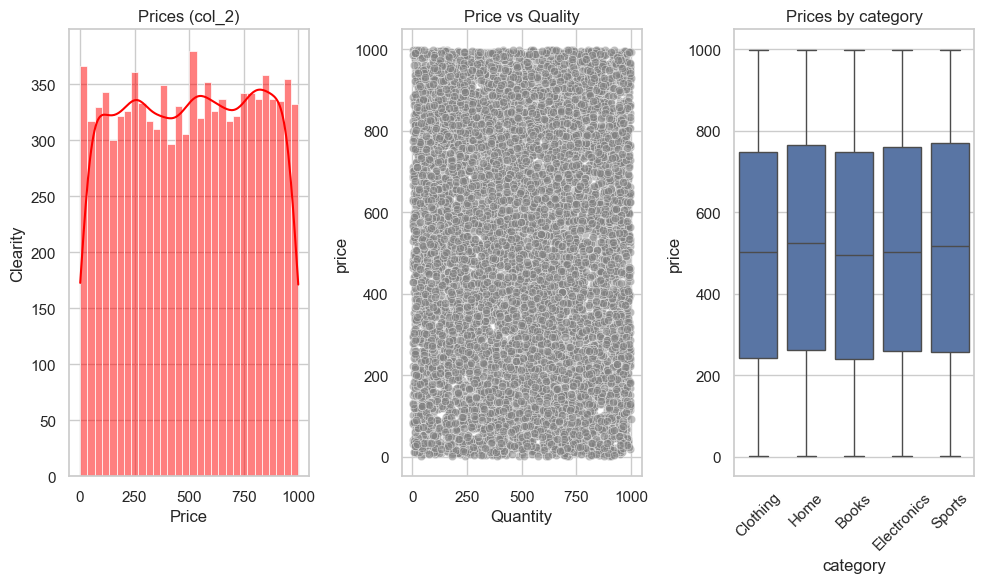

In [69]:
#4
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
sns.histplot(elya['col_2'],bins=30,kde=True,color='red')
plt.title('Prices (col_2)')
plt.xlabel('Price')
plt.ylabel('Clearity')

plt.subplot(1,3,2)
sns.scatterplot(x=elya['col_3'],y=elya['col_2'],alpha=0.5,color='grey')
plt.title('Price vs Quality')
plt.xlabel('Quantity')
plt.ylabel('price')

plt.subplot(1,3,3)
sns.boxplot(x=elya['col_7'],y=elya['col_2'])
plt.title('Prices by category')
plt.xlabel('category')
plt.ylabel('price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [70]:
#5
lowr=elya['col_2'].mean()-3*elya['col_2'].std()
upp=elya['col_2'].mean()+3*elya['col_2'].std()
anomaly=elya[(elya['col_2']<lowr)|(elya['col_2']>upp)]
print(f"found anomaly: {anomaly.shape[0]}")

found anomaly: 0


In [71]:
#6
categorical_cols = elya.select_dtypes(include=['object','str']).columns
elya_encoded=pd.get_dummies(elya,columns=categorical_cols,drop_first=True)
elya_encoded=elya_encoded.astype(float)
print(elya_encoded.dtypes.value_counts())

float64    104
Name: count, dtype: int64


In [72]:
#7
y=elya_encoded['col_2']
neww=['total_value','log_price','double_stock']
X_basic=elya_encoded.drop(columns=['col_2']+neww)
X_adv=elya_encoded.drop(columns=['col_2'])
X_train_basic,X_test_basic,y_train,y_test=train_test_split(X_basic,y,test_size=0.2,random_state=42)
X_train_adv,X_test_adv,_,_=train_test_split(X_adv,y,test_size=0.2,random_state=42)
print(f"Размер обучающей выборки (базовой): {X_train_basic.shape}")
print(f"Размер тестовой выборки: {X_test_basic.shape}")

Размер обучающей выборки (базовой): (8000, 100)
Размер тестовой выборки: (2000, 100)


In [73]:
#8
mb=LinearRegression()
mb.fit(X_train_basic,y_train)
y_pre=mb.predict(X_test_basic)
mae=mean_absolute_error(y_test,y_pre)
mse=mean_squared_error(y_test,y_pre)
print('----Basic model----')
print(f'MAE:,{mae:.2f}')
print(f'MSE:,{mse:.2f}')

----Basic model----
MAE:,250.90
MSE:,84085.18


In [74]:
#9
model_adv=LinearRegression()
model_adv.fit(X_train_adv,y_train)
y_pred=model_adv.predict(X_test_adv)
mae_adv=mean_absolute_error(y_test,y_pred)
mse_adv=mean_squared_error(y_test,y_pred)
print("-----Better way-----")
print(f"MAE:{mae_adv:.2f}")
print(f"MSE:{mse_adv:.2f}")

-----Better way-----
MAE:79.23
MSE:11261.79


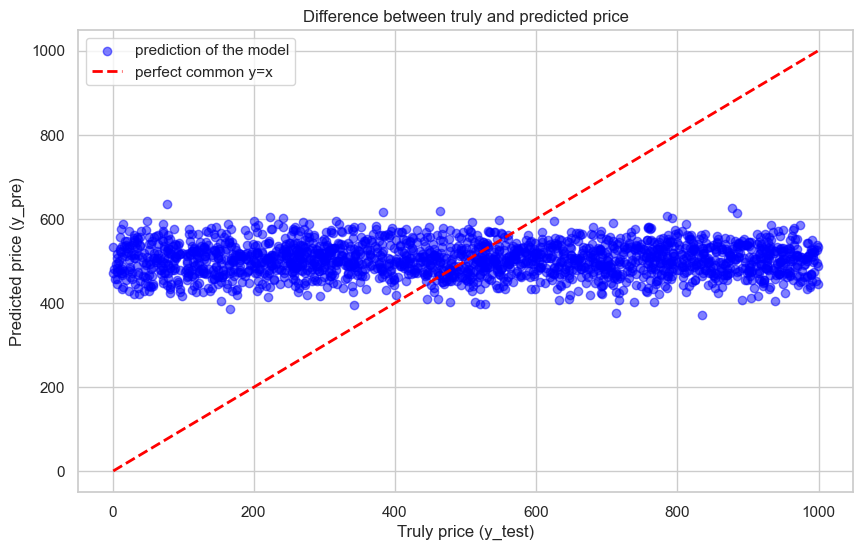

In [75]:
#10
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pre,alpha=0.5,color='blue',label='prediction of the model')
min_val=min(y_test.min(),y_pre.min())
max_val=max(y_test.max(),y_pre.max())
plt.plot([min_val,max_val],[min_val,max_val],color='red',linestyle='--',linewidth=2,label='perfect common y=x')
plt.title('Difference between truly and predicted price')
plt.xlabel('Truly price (y_test)')
plt.ylabel('Predicted price (y_pre)')
plt.legend()
plt.grid(True)
plt.show()

In [76]:
#11
from sklearn.preprocessing import StandardScaler
cols_to_scale=['col_3','col_4','total_value','double_stock','log_price']
cols_to_scale=[col for col in cols_to_scale if col in elya_encoded.columns]
scaler=StandardScaler()
X_adv_scaled=X_adv.copy()
X_adv_scaled[cols_to_scale]=scaler.fit_transform(X_adv[cols_to_scale])
print('"Средние значения после StandardScaler (стремятся к нулю):"')
print(X_adv_scaled[cols_to_scale].mean().round(5))

"Средние значения после StandardScaler (стремятся к нулю):"
col_3          -0.0
total_value    -0.0
double_stock   -0.0
log_price       0.0
dtype: float64


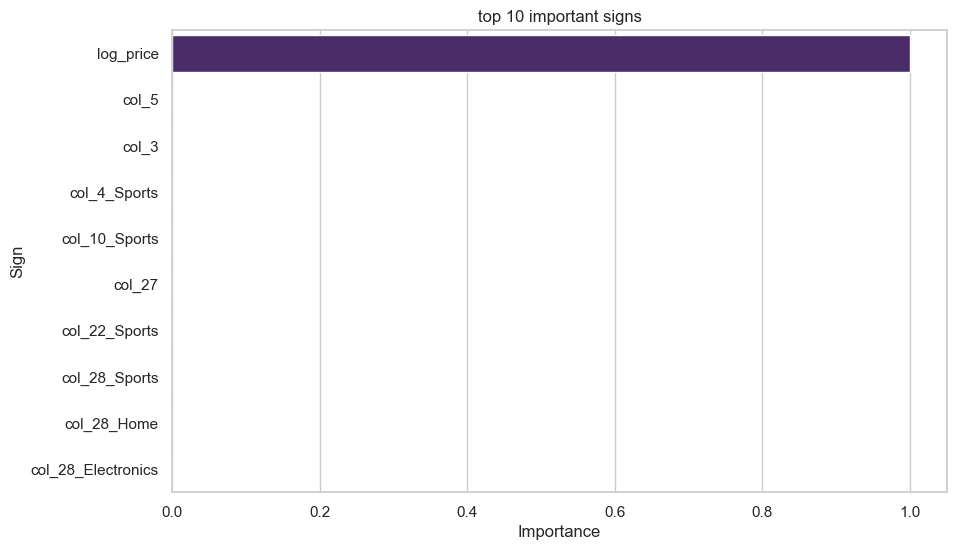

In [77]:
#12
tree_model=DecisionTreeRegressor(random_state=42)
tree_model.fit(X_adv,y)
importances=tree_model.feature_importances_
feature_importances=pd.DataFrame({
    'Feature':X_adv.columns,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_importances.head(10),palette='viridis',hue='Feature',legend=False)
plt.title('top 10 important signs')
plt.xlabel('Importance')
plt.ylabel('Sign')
plt.show()

In [78]:
#13
poly=PolynomialFeatures(degree=2,include_bias=False)
X_poly_train=poly.fit_transform(X_train_basic)
X_poly_test=poly.transform(X_test_basic)
model_poly=LinearRegression()
model_poly.fit(X_poly_train,y_train)
y_pred_poly=model_poly.predict(X_poly_test)
mae_poly=mean_absolute_error(y_test,y_pred_poly)
mse_poly=mean_squared_error(y_test,y_pred_poly)
print(f'MAE:{mae_poly:.2f}')
print(f'MSE:{mse_poly:.2f}')


MAE:374.79
MSE:220699.26


In [79]:
#14
scaler_knn=StandardScaler()
X_train_knn=scaler_knn.fit_transform(X_train_basic)
X_test_knn=scaler_knn.transform(X_test_basic)
knn_model=KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_knn,y_train)
y_pred_knn=knn_model.predict(X_test_knn)
mae_knn=mean_absolute_error(y_test,y_pred_knn)
mse_knn=mean_squared_error(y_test,y_pred_knn)
print(f'MAE:{mae_knn:.2f}')
print(f'MSE:{mse_knn:.2f}')

MAE:272.07
MSE:101999.03



---Category:Clothing---
MAE:256.04


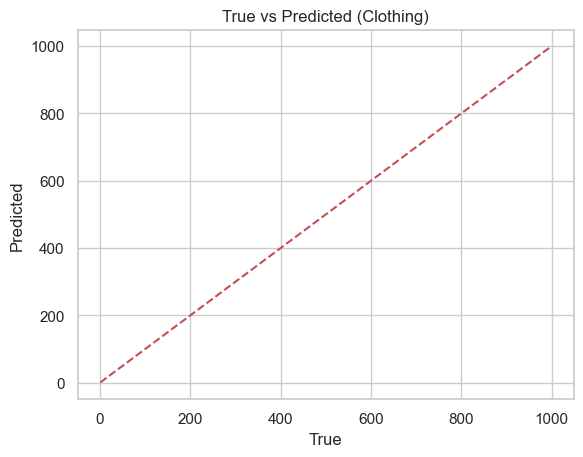

top 3 errors in category Clothing:
True prices : [28. 51. 17.]
Predicted: 4541    671.66
9750    657.82
2050    607.65
dtype: float64

---Category:Home---
MAE:248.50


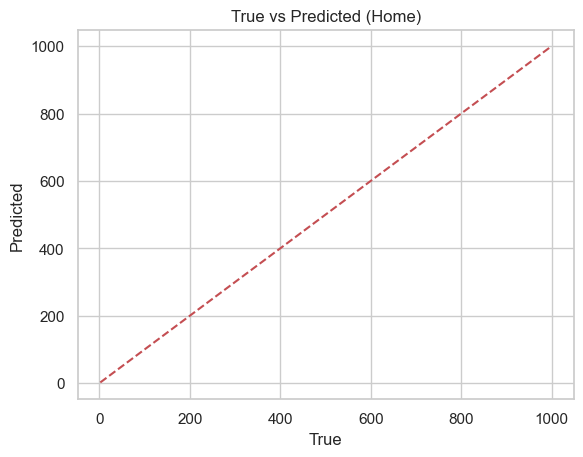

top 3 errors in category Home:
True prices : [999.  13.  13.]
Predicted: 8212    377.73
5444    596.80
1523    593.47
dtype: float64

---Category:Books---
MAE:262.05


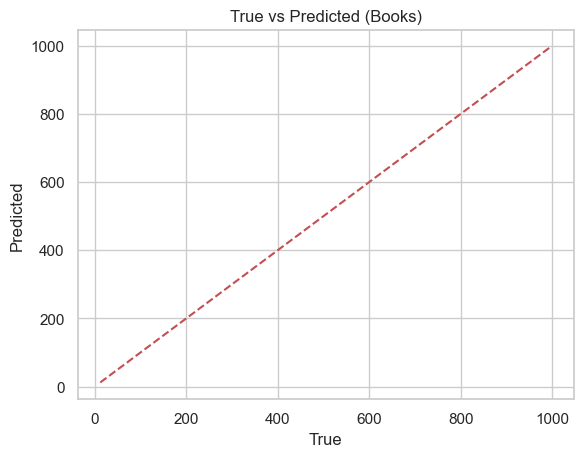

top 3 errors in category Books:
True prices : [988.  51. 962.]
Predicted: 2770    305.09
6283    703.55
9341    338.22
dtype: float64

---Category:Electronics---
MAE:251.34


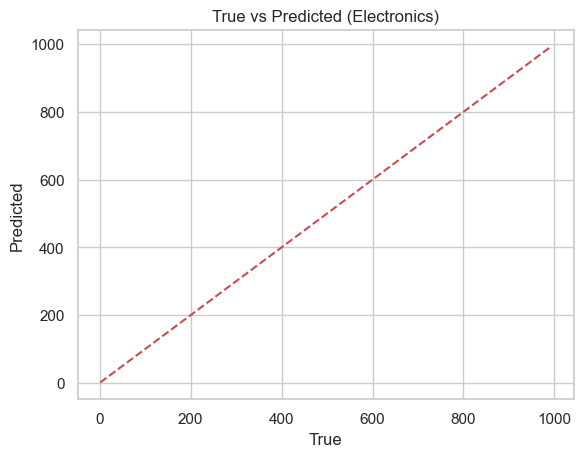

top 3 errors in category Electronics:
True prices : [949.   1.  34.]
Predicted: 5486    348.66
188     598.40
9752    624.32
dtype: float64

---Category:Sports---
MAE:252.97


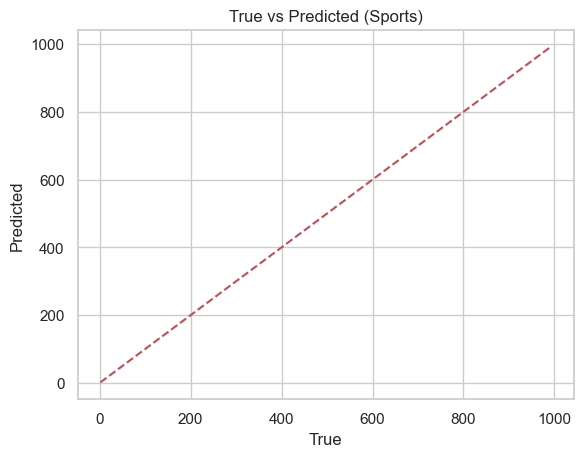

top 3 errors in category Sports:
True prices : [930.   9.  40.]
Predicted: 629     295.22
3223    633.50
4800    660.43
dtype: float64


In [83]:
#15&16
categories=elya['col_7'].unique()
for el in categories:
    print(f'\n---Category:{el}---')
    elya_el=elya[elya['col_7']==el].copy()
    if len(elya_el)<10:
        print('Less than need')
        continue
    X_el=elya_el.drop(columns=['col_2','col_7','total_value','log_price','double_stock'],errors='ignore')
    X_el=pd.get_dummies(X_el,drop_first=True)
    y_el=elya_el['col_2']

    X_tr,X_te,y_tr,y_te=train_test_split(X_el,y_el,test_size=0.2,random_state=42)

    model_el=LinearRegression()
    model_el.fit(X_tr,y_tr)
    y_pr=model_el.predict(X_te)

    print(f'MAE:{mean_absolute_error(y_te,y_pr):.2f}')

    y_pr_series=pd.Series(y_pr,index=y_te.index)

    min_v=min(y_te.min(),y_pr.min())
    max_v=max(y_te.max(),y_pr.max())
    plt.plot([min_v,max_v],[min_v,max_v],'r--')
    plt.title(f'True vs Predicted ({el})')
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.show()
    errors=abs(y_te-y_pr_series)
    worst_idx=errors.nlargest(3).index
    print(f'top 3 errors in category {el}:\nTrue prices : {y_te.loc[worst_idx].values}\nPredicted: {y_pr_series[worst_idx].round(2)}')

In [85]:
#17
scores_mae=cross_val_score(LinearRegression(),X_basic,y,cv=5,scoring='neg_mean_absolute_error')
scores_mse=cross_val_score(LinearRegression(),X_basic,y,cv=5,scoring='neg_mean_squared_error')
cv_mae=-scores_mae.mean()
cv_mse=-scores_mse.mean()
print('---Results Cross-validation---')
print(f'Mean MAE:{cv_mae:.2f}')
print(f'Mean MSE:{cv_mse:.2f}')

---Results Cross-validation---
Mean MAE:251.97
Mean MSE:84876.24


In [87]:
#18
bins=[-np.inf,100,500,np.inf]
labels=[0,1,2]
y_class=pd.cut(elya_encoded['col_2'],bins=bins,labels=labels)
X_train_clf,X_test_clf,y_train_clf,y_test_clf=train_test_split(X_basic,y_class,test_size=0.2,random_state=42)
clf=DecisionTreeClassifier(max_depth=5,random_state=42)
clf.fit(X_train_clf,y_train_clf)
y_pred_clf=clf.predict(X_test_clf)
acc=accuracy_score(y_test_clf,y_pred_clf)
print(f'Classification Accuracy:{acc*100:.1f}%')

Classification Accuracy:48.1%


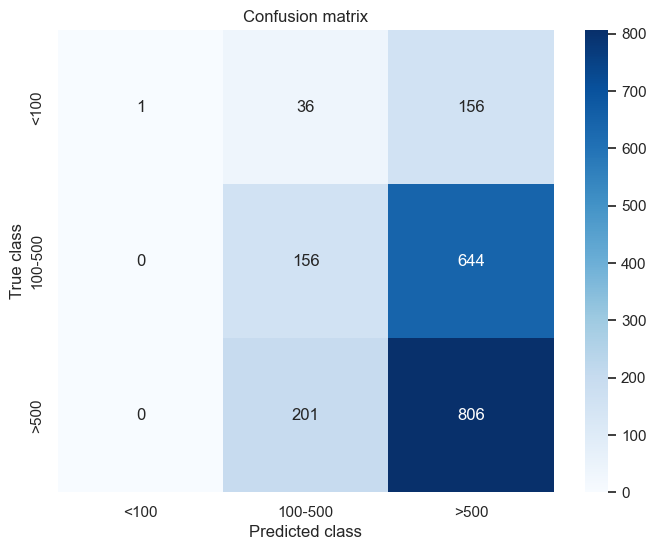

In [91]:
#19
cm=confusion_matrix(y_test_clf,y_pred_clf)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['<100','100-500','>500'],yticklabels=['<100','100-500','>500'])
plt.title("Confusion matrix")
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.show()

In [92]:
#20
final_predictions=model_basic.predict(X_basic)
elya_final=elya.copy()
elya_final['predicted_price']=final_predictions
output_file='catalog_ml-predictions.xlsx'
elya_final.to_excel(output_file,index=False)
print(f'Results in file:{output_file}')

fig,axes=plt.subplot(1,2,figsize=(15,6))
axes[0].scatter(elya_final['col_2'],elya_final['predicted_price'],alpha=0.3,color='purple')
min_val=min(elya_final['col_2'].min(),elya_final['predicted_price'].min())
max_val=max(elya_final['col_2'].max(),elya_final['predicted_price'].max())
axes[0].plot([min_val,max_val],[min_val,max_val],'r--')
axes[0].set_title('true vs predicted price')
axes[0].set_xlabel('true')
axes[0].set_ylabel('predicted')

sns.kdeplot(elya_final['col_2'],label='True',ax=axes[1],color='blue',fill=True)
sns.kdeplot(elya_final['predicted_price'],label='ptedicted',ax=axes[1],xolor='orange',fill=True)
axes[1].set_title('Price')
axes[1].legend()
plt.tight_layout()
plt.show()

NameError: name 'model_basic' is not defined